# AI Workforce Intelligence Platform

# XGBoost Experiments

## Objective

The objective of this notebook is to evaluate the performance of XGBoost for employee attrition prediction under different class imbalance handling strategies.

Five experimental settings are evaluated:

- Baseline (No Resampling)
- Random Oversampling
- SMOTE
- ADASYN
- XGBoost Class Weights

Each experiment is assessed using multiple evaluation metrics, allowing an evidence-based comparison of different imbalance handling techniques.

05 XGBoost Experiments Walkthrough:

1. Import Libraries
2. Load Processed Data
3. Reusable Functions (for ease)
4. Baseline Model
5. Random Oversampling
6. SMOTE
7. ADASYN
8. Class Weight
9. Compare Results
10. Feature Importance
11. Save Best Model
12. Notebook Conclusion

### Step 1 - Imports

In [2]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.5/69.5 MB 1.6 MB/s eta 0:00:44
   ---------------------------------------- 0.5/69.5 MB 1.6 MB/s eta 0:00:44
    --------------------------------------- 1.0/69.5 MB 1.4 MB/s eta 0:00:51
    --------------------------------------- 1.3/69.5 MB 1.5 MB/s eta 0:00:46
    --------------------------------------- 1.6/69.5 MB 1.4 MB/s eta 0:00:48
   - -------------------------------------- 2.4/69.5 MB 1.7 MB/s eta 0:00:40
   - -------------------------------------- 2.9/69.5 MB 1.9 MB/s eta 0:00:36
   -- ------------------------------------- 3.7/69.5 MB 2.2 MB/s eta 0:00:31
   -- ------------------------------------- 4.2/69.5 MB 2.2 MB/s eta 0:00:31
   -- -------------

In [4]:
!pip install imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable

   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-

In [5]:
import warnings
warnings.filterwarnings("ignore")

import time
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

from imblearn.over_sampling import (
    RandomOverSampler,
    SMOTE,
    ADASYN
)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)

In [100]:
from pathlib import Path

In [101]:
evaluation_path = Path("..//reports//figures//model_evaluation//xgboost")

evaluation_path.mkdir(
    parents=True,
    exist_ok=True
)

### Step 2 - Load Data

In [6]:
X_train = pd.read_csv("..//data//processed//X_train_processed.csv")

X_test = pd.read_csv("..//data//processed//X_test_processed.csv")

y_train = pd.read_csv("..//data//processed//y_train.csv").squeeze()

y_test = pd.read_csv("..//data//processed//y_test.csv").squeeze()

In [7]:
print(X_train.shape)

print(X_test.shape)

print(y_train.shape)

print(y_test.shape)

(1176, 114)
(294, 114)
(1176,)
(294,)


### Step 3 - Reusable Functions

### Function 1 - Train Model

In [103]:
def train_xgboost(
    X_train,
    y_train,
    scale_pos_weight=None
):
    
    model = XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight
    )

    start = time.time()

    model.fit(
        X_train,
        y_train
    )

    end = time.time()

    training_time = end - start

    return model, training_time

## Function 2 - Evaluation

In [104]:
def evaluate_model(
    model,
    X_test,
    y_test
):

    predictions = model.predict(X_test)

    probabilities = model.predict_proba(
        X_test
    )[:,1]

    metrics = {
        "Accuracy":
            accuracy_score(
                y_test,
                predictions
            ),

        "Precision":
            precision_score(
                y_test,
                predictions
            ),

        "Recall":
            recall_score(
                y_test,
                predictions
            ),

        "F1":
            f1_score(
                y_test,
                predictions
            ),

        "ROC-AUC":
            roc_auc_score(
                y_test,
                probabilities
            ),

        "PR-AUC":
            average_precision_score(
                y_test,
                probabilities
            )
    }

    return (
        predictions,
        probabilities,
        metrics
    )

### Function 3 - Visualization Function

In [105]:
def plot_evaluation(
    model,
    X_test,
    y_test,
    predictions,
    probabilities,
    experiment_name
):

    experiment_folder = evaluation_path / experiment_name.replace(" ", "_")

    experiment_folder.mkdir(
        parents=True,
        exist_ok=True
    )

    # -----------------------------
    # Confusion Matrix
    # -----------------------------

    plt.figure(figsize=(5,5))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions
    )

    plt.title(f"{experiment_name} - Confusion Matrix")

    plt.tight_layout()

    plt.savefig(
        experiment_folder / "confusion_matrix.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()

    # -----------------------------
    # ROC Curve
    # -----------------------------

    plt.figure(figsize=(6,5))

    RocCurveDisplay.from_predictions(
        y_test,
        probabilities
    )

    plt.title(f"{experiment_name} - ROC Curve")

    plt.tight_layout()

    plt.savefig(
        experiment_folder / "roc_curve.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()

    # -----------------------------
    # Precision Recall Curve
    # -----------------------------

    plt.figure(figsize=(6,5))

    PrecisionRecallDisplay.from_predictions(
        y_test,
        probabilities
    )

    plt.title(f"{experiment_name} - Precision Recall Curve")

    plt.tight_layout()

    plt.savefig(
        experiment_folder / "precision_recall_curve.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()

### Function 4 - Store Results Function

In [106]:
def save_results(
    experiment_name,
    sampling_method,
    balanced,
    training_samples,
    metrics,
    training_time
):

    results.append({

        "Model": "XGBoost",

        "Experiment": experiment_name,

        "Sampling Method": sampling_method,

        "Balanced Dataset": balanced,

        "Training Samples": training_samples,

        "Accuracy": metrics["Accuracy"],

        "Precision": metrics["Precision"],

        "Recall": metrics["Recall"],

        "F1 Score": metrics["F1"],

        "ROC-AUC": metrics["ROC-AUC"],

        "PR-AUC": metrics["PR-AUC"],

        "Training Time (Seconds)": training_time

    })

### Function 5 - Initiate Results Function

In [107]:
results = []

## Step 4. Baseline Model (No Resampling)

The first experiment trains XGBoost using the original imbalanced training dataset without applying any resampling technique.

This serves as the baseline against which all subsequent imbalance handling methods will be compared.

The evaluation metrics obtained here provide a reference for determining whether oversampling or class weighting improves predictive performance.

#### 4.1 Train Model

In [108]:
baseline_model, baseline_time = train_xgboost(
    X_train,
    y_train
)

#### 4.2 Evaluate Model

In [109]:
baseline_predictions, baseline_probabilities, baseline_metrics = evaluate_model(
    baseline_model,
    X_test,
    y_test
)

#### 4.3 Classification Reports

In [110]:
print("=" * 60)
print("BASELINE MODEL")
print("=" * 60)

print(classification_report(
    y_test,
    baseline_predictions
))

BASELINE MODEL
              precision    recall  f1-score   support

           0       0.88      0.98      0.93       247
           1       0.72      0.28      0.40        47

    accuracy                           0.87       294
   macro avg       0.80      0.63      0.66       294
weighted avg       0.85      0.87      0.84       294



#### 4.4 Visualization

<Figure size 500x500 with 0 Axes>

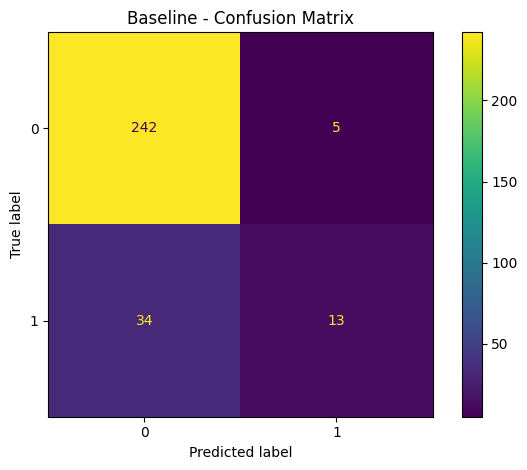

<Figure size 600x500 with 0 Axes>

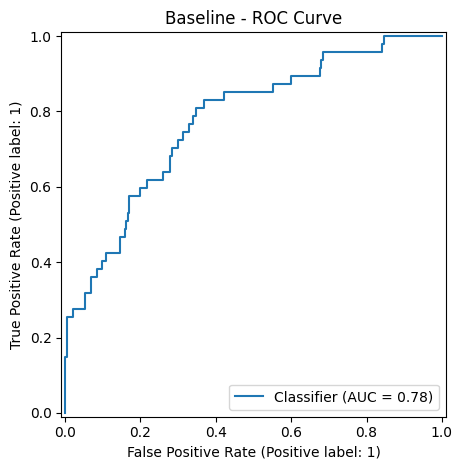

<Figure size 600x500 with 0 Axes>

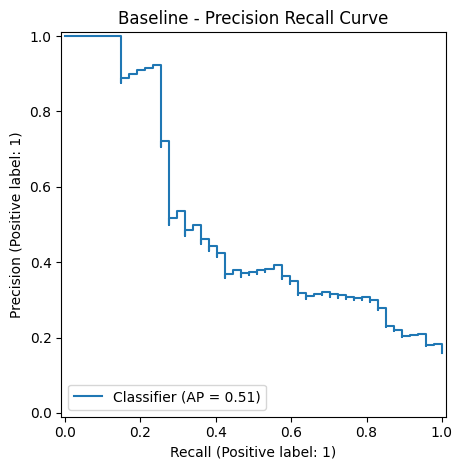

In [111]:
plot_evaluation(
    baseline_model,
    X_test,
    y_test,
    baseline_predictions,
    baseline_probabilities,
    "Baseline"
)

#### 4.5 Save Results

In [112]:
save_results(
    experiment_name="Baseline",
    sampling_method="None",
    balanced="No",
    training_samples=len(X_train),
    metrics=baseline_metrics,
    training_time=baseline_time
)

In [113]:
report = classification_report(
    y_test,
    baseline_predictions
)

print(report)

with open(
    "..//reports//tables//baseline_classification_report.txt",
    "w"
) as file:

    file.write(report)

              precision    recall  f1-score   support

           0       0.88      0.98      0.93       247
           1       0.72      0.28      0.40        47

    accuracy                           0.87       294
   macro avg       0.80      0.63      0.66       294
weighted avg       0.85      0.87      0.84       294



### Step 5. Random Oversampling

Random Oversampling balances the training dataset by randomly duplicating minority-class samples until both classes contain an equal number of observations.

Although simple, this technique may increase the risk of overfitting because duplicated observations do not introduce new information.

#### 5.1 Apply Random Oversampling

In [114]:
ros = RandomOverSampler(
    random_state=42
)

X_train_ros, y_train_ros = ros.fit_resample(
    X_train,
    y_train
)

#### 5.2 Verify Class Distribution

In [115]:
print(y_train_ros.value_counts())

Attrition
0    986
1    986
Name: count, dtype: int64


#### 5.3 Train Model

In [116]:
ros_model, ros_time = train_xgboost(
    X_train_ros,
    y_train_ros
)

#### 5.4 Evaluate

In [117]:
ros_predictions, ros_probabilities, ros_metrics = evaluate_model(
    ros_model,
    X_test,
    y_test
)

#### 5.5 Classification Report

In [118]:
print("=" * 60)
print("RANDOM OVERSAMPLING")
print("=" * 60)

print(classification_report(
    y_test,
    ros_predictions
))

RANDOM OVERSAMPLING
              precision    recall  f1-score   support

           0       0.88      0.94      0.91       247
           1       0.52      0.32      0.39        47

    accuracy                           0.84       294
   macro avg       0.70      0.63      0.65       294
weighted avg       0.82      0.84      0.83       294



#### 5.6 Visualizations

<Figure size 500x500 with 0 Axes>

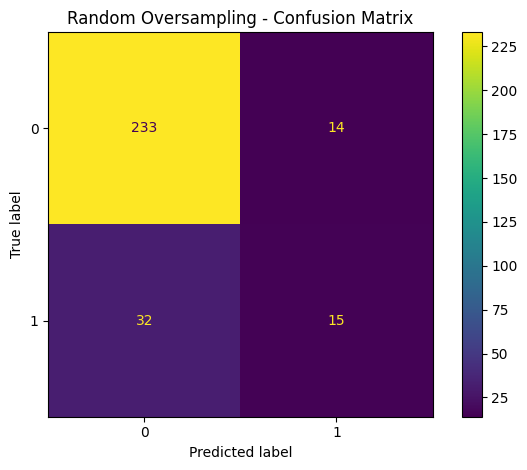

<Figure size 600x500 with 0 Axes>

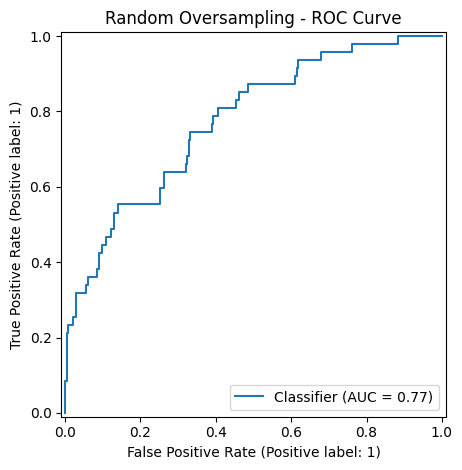

<Figure size 600x500 with 0 Axes>

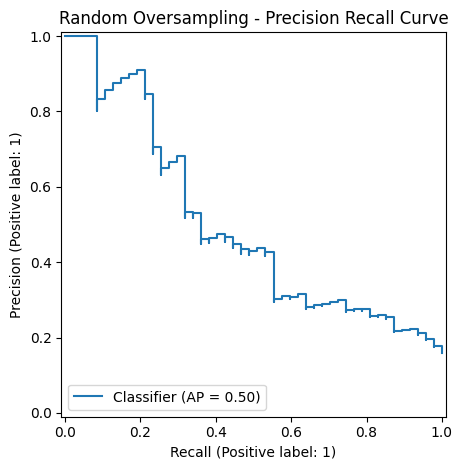

In [119]:
plot_evaluation(
    ros_model,
    X_test,
    y_test,
    ros_predictions,
    ros_probabilities,
    "Random Oversampling"
)

#### 5.7 Save Results

In [120]:
save_results(
    experiment_name="Random Oversampling",
    sampling_method="RandomOverSampler",
    balanced="Yes",
    training_samples=len(X_train_ros),
    metrics=ros_metrics,
    training_time=ros_time
)

In [121]:
report = classification_report(
    y_test,
    ros_predictions
)

print(report)

with open(
    "..//reports//tables//random_oversampling_classification_report.txt",
    "w"
) as file:

    file.write(report)

              precision    recall  f1-score   support

           0       0.88      0.94      0.91       247
           1       0.52      0.32      0.39        47

    accuracy                           0.84       294
   macro avg       0.70      0.63      0.65       294
weighted avg       0.82      0.84      0.83       294



## Step 6. SMOTE

SMOTE (Synthetic Minority Over-sampling Technique) generates synthetic minority-class observations by interpolating between existing minority samples.

Unlike Random Oversampling, SMOTE creates new synthetic observations rather than duplicating existing ones, potentially improving generalization.

#### 6.1 Apply SMOTE

In [122]:
smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

#### 6.2 Verify Distribution

In [123]:
print(y_train_smote.value_counts())

Attrition
0    986
1    986
Name: count, dtype: int64


#### 6.3 Train Model

In [124]:
smote_model, smote_time = train_xgboost(
    X_train_smote,
    y_train_smote
)

#### 6.4 Evaluate

In [125]:
smote_predictions, smote_probabilities, smote_metrics = evaluate_model(
    smote_model,
    X_test,
    y_test
)

#### 6.5 Classification Report

In [126]:
print("=" * 60)
print("SMOTE")
print("=" * 60)

print(classification_report(
    y_test,
    smote_predictions
))

SMOTE
              precision    recall  f1-score   support

           0       0.88      0.95      0.91       247
           1       0.56      0.32      0.41        47

    accuracy                           0.85       294
   macro avg       0.72      0.64      0.66       294
weighted avg       0.83      0.85      0.83       294



#### 6.6 Visualizations

<Figure size 500x500 with 0 Axes>

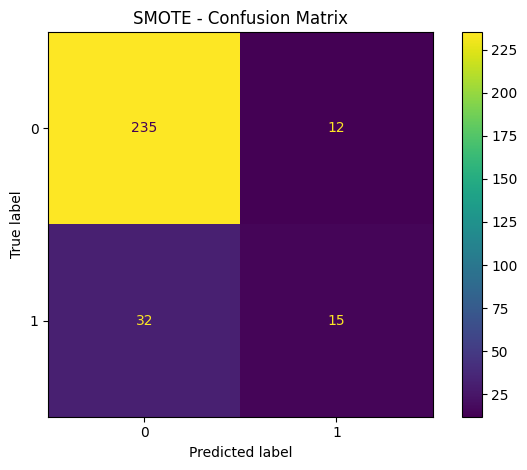

<Figure size 600x500 with 0 Axes>

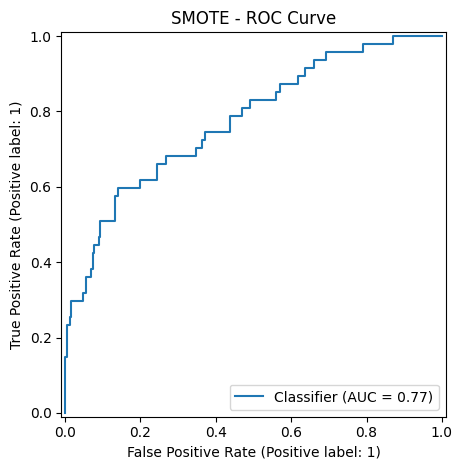

<Figure size 600x500 with 0 Axes>

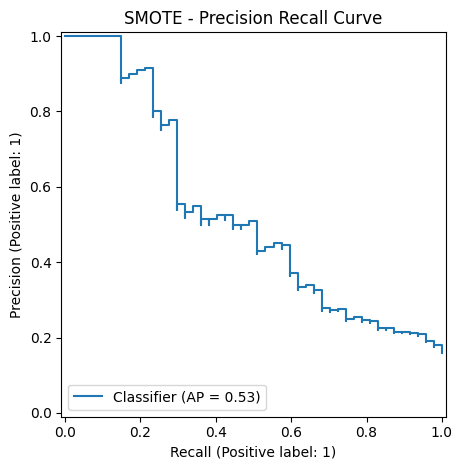

In [127]:
plot_evaluation(
    smote_model,
    X_test,
    y_test,
    smote_predictions,
    smote_probabilities,
    "SMOTE"
)

#### 6.7 Save Results

In [128]:
save_results(
    experiment_name="SMOTE",
    sampling_method="SMOTE",
    balanced="Yes",
    training_samples=len(X_train_smote),
    metrics=smote_metrics,
    training_time=smote_time
)

In [129]:
report = classification_report(
    y_test,
    smote_predictions
)

print(report)

with open(
    "..//reports//tables//smote_classification_report.txt",
    "w"
) as file:

    file.write(report)

              precision    recall  f1-score   support

           0       0.88      0.95      0.91       247
           1       0.56      0.32      0.41        47

    accuracy                           0.85       294
   macro avg       0.72      0.64      0.66       294
weighted avg       0.83      0.85      0.83       294



## 7. ADASYN

Adaptive Synthetic Sampling (ADASYN) is an extension of SMOTE that focuses on generating synthetic samples in regions where the minority class is more difficult to learn.

Unlike SMOTE, which generates samples uniformly, ADASYN adaptively creates more synthetic observations near difficult decision boundaries, potentially improving minority-class recognition.

#### 7.1 Apply ADASYN

In [130]:
adasyn = ADASYN(
    random_state=42
)

X_train_adasyn, y_train_adasyn = adasyn.fit_resample(
    X_train,
    y_train
)

#### 7.2 Verify Distribution

In [131]:
print(y_train_adasyn.value_counts())

Attrition
0    986
1    970
Name: count, dtype: int64


#### 7.3 Train Model

In [132]:
adasyn_model, adasyn_time = train_xgboost(
    X_train_adasyn,
    y_train_adasyn
)

#### 7.4 Evaluate Model

In [133]:
adasyn_predictions, adasyn_probabilities, adasyn_metrics = evaluate_model(
    adasyn_model,
    X_test,
    y_test
)

#### 7.5 Classification Report

In [134]:
print("=" * 60)
print("ADASYN")
print("=" * 60)

print(
    classification_report(
        y_test,
        adasyn_predictions
    )
)

ADASYN
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       247
           1       0.62      0.32      0.42        47

    accuracy                           0.86       294
   macro avg       0.75      0.64      0.67       294
weighted avg       0.84      0.86      0.84       294



#### 7.6 Visualizations

<Figure size 500x500 with 0 Axes>

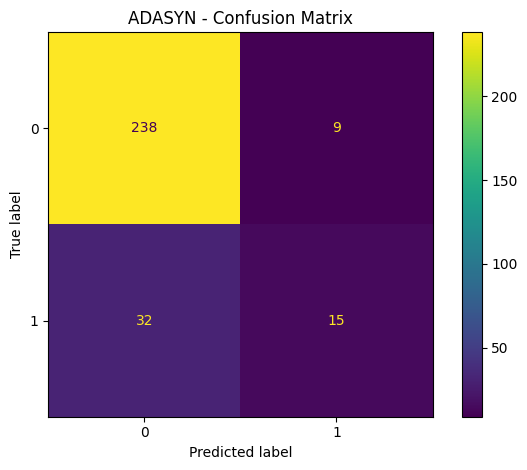

<Figure size 600x500 with 0 Axes>

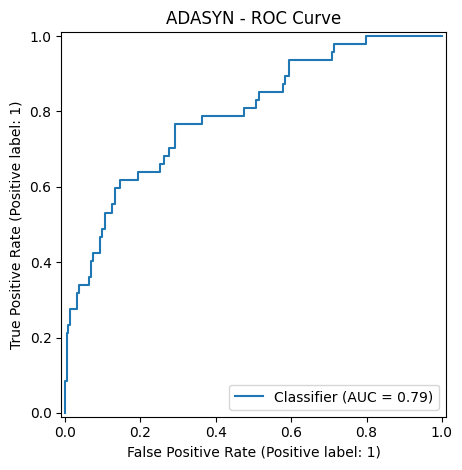

<Figure size 600x500 with 0 Axes>

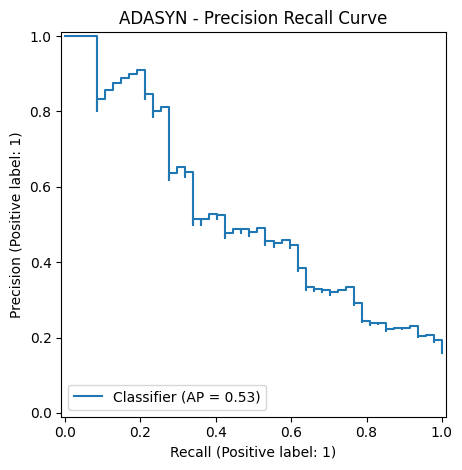

In [135]:
plot_evaluation(
    adasyn_model,
    X_test,
    y_test,
    adasyn_predictions,
    adasyn_probabilities,
    "ADASYN"
)

#### 7.7 Save Results

In [136]:
save_results(
    experiment_name="ADASYN",
    sampling_method="ADASYN",
    balanced="Yes",
    training_samples=len(X_train_adasyn),
    metrics=adasyn_metrics,
    training_time=adasyn_time
)

In [137]:
report = classification_report(
    y_test,
    adasyn_predictions
)

print(report)

with open(
    "..//reports//tables//adasyn_classification_report.txt",
    "w"
) as file:

    file.write(report)

              precision    recall  f1-score   support

           0       0.88      0.96      0.92       247
           1       0.62      0.32      0.42        47

    accuracy                           0.86       294
   macro avg       0.75      0.64      0.67       294
weighted avg       0.84      0.86      0.84       294



## 8. Class Weight

Instead of modifying the training data, XGBoost can directly account for class imbalance by assigning a larger penalty to misclassified minority-class observations.

The `scale_pos_weight` parameter increases the importance of attrition cases during training while preserving the original dataset.

#### 8.1 Calculate Class Weight

In [138]:
negative = (y_train == 0).sum()

positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print(f"Scale Positive Weight : {scale_pos_weight:.2f}")

Scale Positive Weight : 5.19


#### 8.2 Train Model

In [139]:
class_weight_model, class_weight_time = train_xgboost(
    X_train,
    y_train,
    scale_pos_weight=scale_pos_weight
)

#### 8.3 Evaluate Model

In [140]:
class_weight_predictions, class_weight_probabilities, class_weight_metrics = evaluate_model(
    class_weight_model,
    X_test,
    y_test
)

#### 8.4 Classification Report

In [141]:
print("=" * 60)
print("CLASS WEIGHT")
print("=" * 60)

print(
    classification_report(
        y_test,
        class_weight_predictions
    )
)

CLASS WEIGHT
              precision    recall  f1-score   support

           0       0.88      0.94      0.91       247
           1       0.50      0.32      0.39        47

    accuracy                           0.84       294
   macro avg       0.69      0.63      0.65       294
weighted avg       0.82      0.84      0.83       294



#### 8.5 Visualizations

<Figure size 500x500 with 0 Axes>

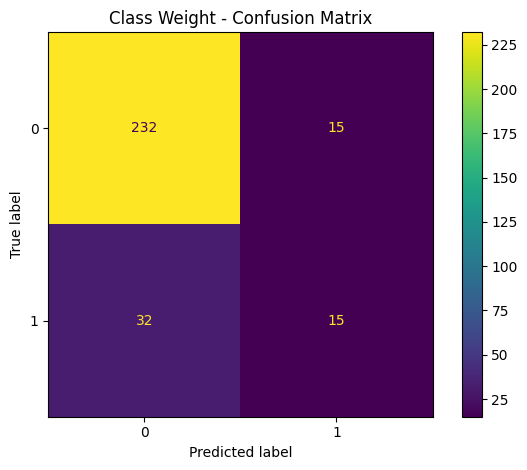

<Figure size 600x500 with 0 Axes>

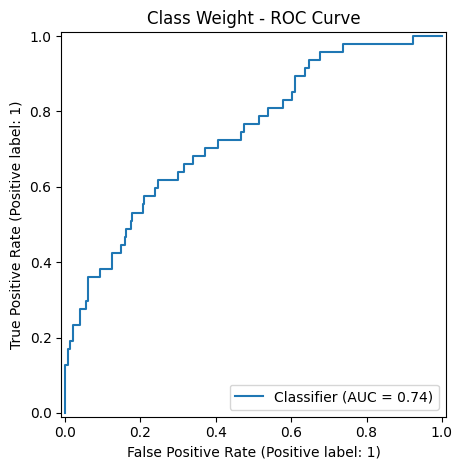

<Figure size 600x500 with 0 Axes>

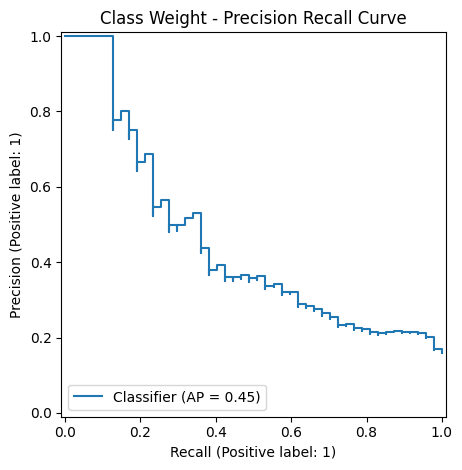

In [142]:
plot_evaluation(
    class_weight_model,
    X_test,
    y_test,
    class_weight_predictions,
    class_weight_probabilities,
    "Class Weight"
)

#### 8.6 Save Results

In [143]:
save_results(
    experiment_name="Class Weight",
    sampling_method="Scale Pos Weight",
    balanced="No",
    training_samples=len(X_train),
    metrics=class_weight_metrics,
    training_time=class_weight_time
)

In [144]:
report = classification_report(
    y_test,
    class_weight_predictions
)

print(report)

with open(
    "..//reports//tables//class_weight_classification_report.txt",
    "w"
) as file:

    file.write(report)

              precision    recall  f1-score   support

           0       0.88      0.94      0.91       247
           1       0.50      0.32      0.39        47

    accuracy                           0.84       294
   macro avg       0.69      0.63      0.65       294
weighted avg       0.82      0.84      0.83       294



### Step 9. Compare Results

#### 9.1 Create Results DataFrame

In [145]:
results_df = pd.DataFrame(results)

#### 9.2 Round Values

In [146]:
metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC",
    "PR-AUC",
    "Training Time (Seconds)"
]

results_df[metric_columns] = results_df[
    metric_columns
].round(4)

#### 9.3 Sort by F1 Score

In [147]:
results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

#### 9.4 Display Results

In [148]:
display(results_df)

,Model,Experiment,Sampling Method,Balanced Dataset,Training Samples,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC,Training Time (Seconds)
0,XGBoost,ADASYN,ADASYN,Yes,1956,0.861,0.625,0.319,0.422,0.792,0.529,0.435
1,XGBoost,SMOTE,SMOTE,Yes,1972,0.850,0.556,0.319,0.405,0.774,0.528,0.400
2,XGBoost,Baseline,None,No,1176,0.867,0.722,0.277,0.400,0.776,0.507,0.207
3,XGBoost,Random Oversampling,RandomOverSampler,Yes,1972,0.844,0.517,0.319,0.395,0.773,0.499,0.162
4,XGBoost,Class Weight,Scale Pos Weight,No,1176,0.840,0.500,0.319,0.390,0.740,0.454,0.129


#### 9.5 Save Results

In [149]:
results_df.to_csv(
    "..//reports//tables//xgboost_experiment_results.csv",
    index=False
)

print("Results saved successfully.")

Results saved successfully.


#### 9.6 Ranking

In [150]:
results_df["F1 Rank"] = results_df[
    "F1 Score"
].rank(
    ascending=False
)

results_df["ROC Rank"] = results_df[
    "ROC-AUC"
].rank(
    ascending=False
)

results_df["PR Rank"] = results_df[
    "PR-AUC"
].rank(
    ascending=False
)

results_df["Time Rank"] = results_df[
    "Training Time (Seconds)"
].rank(
    ascending=True
)

In [151]:
results_df["Overall Rank"] = (

    results_df["F1 Rank"]

    + results_df["ROC Rank"]

    + results_df["PR Rank"]

    + results_df["Time Rank"]

) / 4

In [152]:
results_df = results_df.sort_values(
    by="Overall Rank"
).reset_index(drop=True)

In [153]:
results_df.to_csv(
    "..//reports//tables//xgboost_experiment_ranking.csv",
    index=False
)

## 10. Feature Importance

The best-performing XGBoost model is used to identify the most influential predictors of employee attrition.

Feature importance provides insight into which variables contribute most to the model's decisions and serves as a preliminary interpretability analysis before applying SHAP in a later notebook.

#### 10.1 Identify Best Model

In [154]:
models = {
    "Baseline": baseline_model,
    "Random Oversampling": ros_model,
    "SMOTE": smote_model,
    "ADASYN": adasyn_model,
    "Class Weight": class_weight_model
}

best_experiment = results_df.iloc[0]["Experiment"]

best_model = models[best_experiment]

print(f"Best Model : {best_experiment}")

Best Model : ADASYN


#### 10.2 Extract Feature Importance

In [155]:
feature_importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": best_model.feature_importances_

})

#### 10.3 Sort

In [156]:
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

#### 10.4 Display Top 20

In [157]:
display(
    feature_importance.head(20)
)

,Feature,Importance
64,MaritalStatus_Single,0.147
103,ManagerStabilityLevel_Low,0.114
43,Department_Research & Development,0.046
110,TenureCommitment_High,0.041
55,JobRole_Laboratory Technician,0.031
7,JobLevel,0.031
24,OvertimeRisk,0.029
89,WellbeingLevel_Very High,0.025
60,JobRole_Sales Executive,0.023
57,JobRole_Manufacturing Director,0.023


#### 10.5 Plot

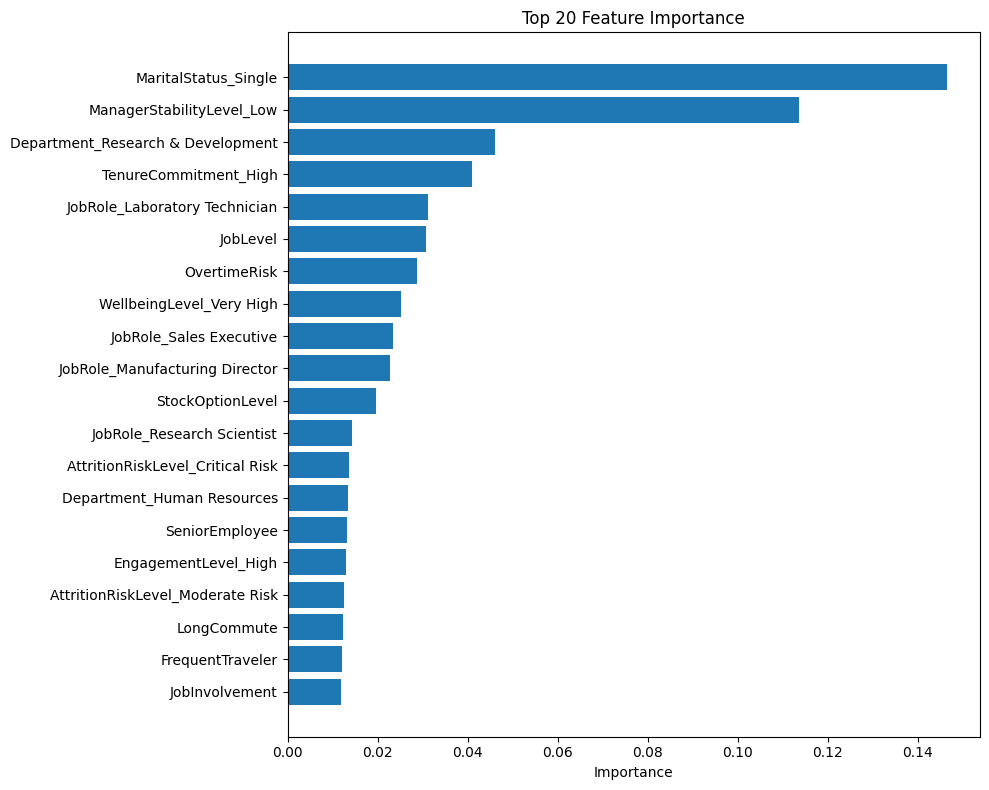

In [159]:
feature_engineering_path = Path(
    "..//reports//figures//feature_engineering"
)

feature_engineering_path.mkdir(
    parents=True,
    exist_ok=True
)

plt.figure(figsize=(10,8))

plt.barh(
    feature_importance.head(20)["Feature"][::-1],
    feature_importance.head(20)["Importance"][::-1]
)

plt.title("Top 20 Feature Importance")

plt.xlabel("Importance")

plt.tight_layout()

plt.savefig(
    feature_engineering_path / "xgboost_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

In [160]:
comparison_path = Path(
    "..//reports//figures//model_comparison"
)

comparison_path.mkdir(
    parents=True,
    exist_ok=True
)

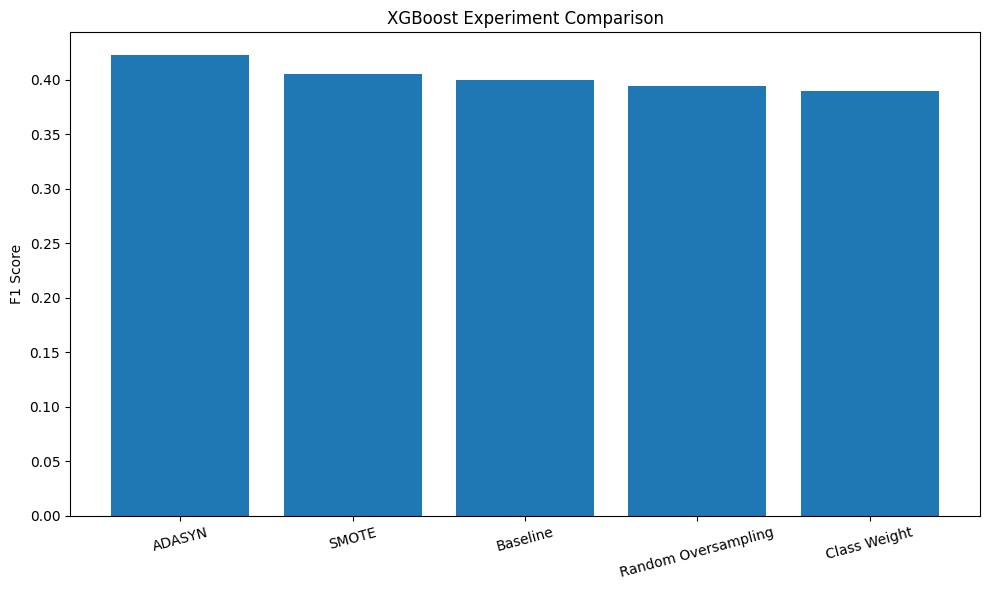

In [161]:
plt.figure(figsize=(10,6))

plt.bar(
    results_df["Experiment"],
    results_df["F1 Score"]
)

plt.title("XGBoost Experiment Comparison")

plt.ylabel("F1 Score")

plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    comparison_path / "experiment_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

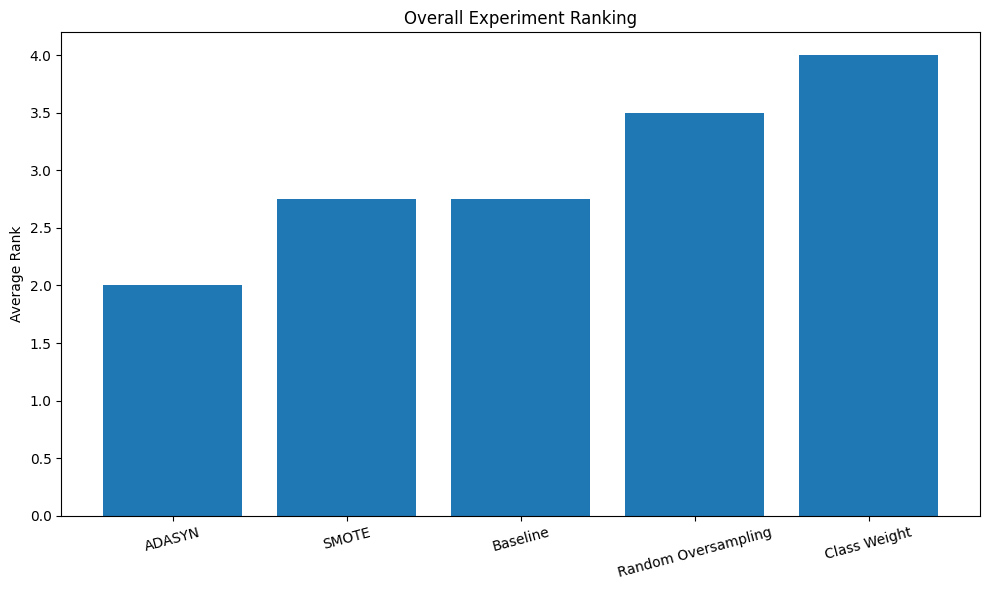

In [162]:
plt.figure(figsize=(10,6))

plt.bar(
    results_df["Experiment"],
    results_df["Overall Rank"]
)

plt.title("Overall Experiment Ranking")

plt.ylabel("Average Rank")

plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    comparison_path / "ranking_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

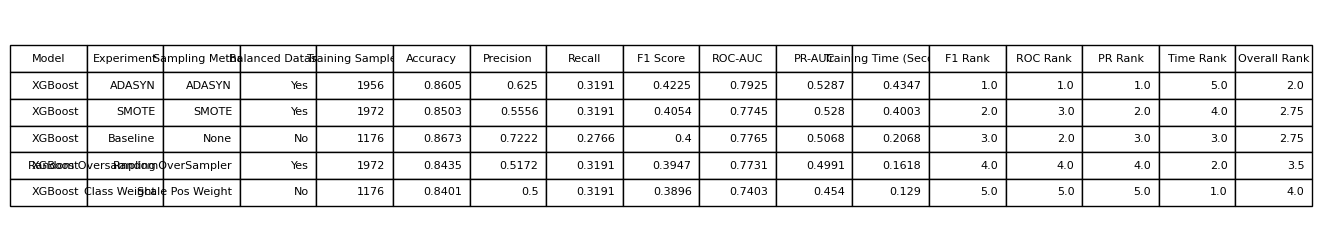

In [163]:
fig, ax = plt.subplots(figsize=(14,3))

ax.axis("off")

table = ax.table(
    cellText=results_df.round(4).values,
    colLabels=results_df.columns,
    loc="center"
)

table.auto_set_font_size(False)

table.set_fontsize(8)

table.scale(1.2, 1.6)

plt.savefig(
    comparison_path / "experiment_results_table.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

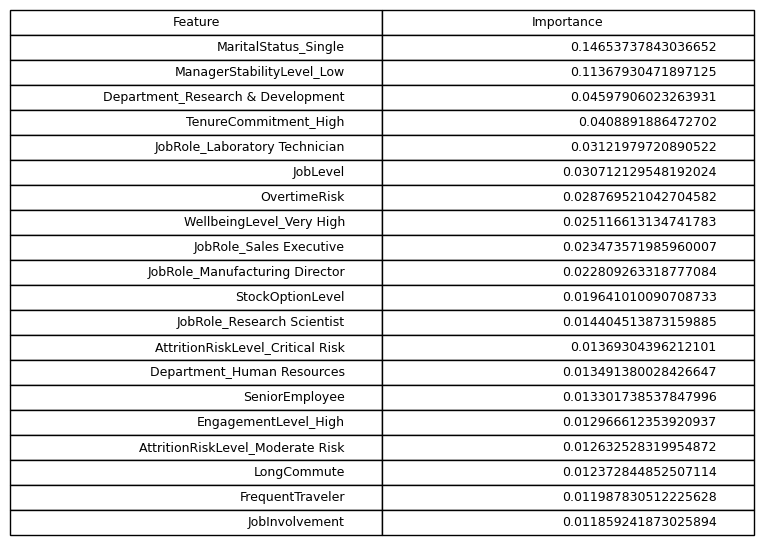

In [164]:
top20 = feature_importance.head(20)

fig, ax = plt.subplots(figsize=(8,6))

ax.axis("off")

table = ax.table(
    cellText=top20.values,
    colLabels=top20.columns,
    loc="center"
)

table.auto_set_font_size(False)

table.set_fontsize(9)

table.scale(1.2,1.5)

plt.savefig(
    feature_engineering_path / "top20_features_table.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

#### 10.6 Save

In [165]:
feature_importance.to_csv(
    "..//reports//tables//xgboost_feature_importance.csv",
    index=False
)

## 11. Save Best Model

In [166]:
joblib.dump(
    best_model,
    "..//models//xgboost_best_model.pkl"
)

print("Best model saved successfully.")

Best model saved successfully.


In [167]:
best_model_summary = results_df.iloc[[0]]

best_model_summary.to_csv(
    "..//reports//tables//best_xgboost_model.csv",
    index=False
)

In [168]:
feature_importance.head(20).to_csv(
    "..//reports//tables//top20_xgboost_features.csv",
    index=False
)

# Conclusion

This notebook evaluated XGBoost under five different strategies for handling class imbalance:

- Baseline (No Resampling)
- Random Oversampling
- SMOTE
- ADASYN
- Class Weighting

Each model was assessed using Accuracy, Precision, Recall, F1 Score, ROC-AUC, PR-AUC, and Training Time.

The comparison demonstrated how different imbalance handling techniques affect predictive performance, allowing the most effective strategy to be selected based on objective evaluation metrics.

The best-performing model has been saved for subsequent explainability analysis and integration into the AI Workforce Intelligence Platform.

The next notebook will focus on developing a Deep Learning model using a Neural Network and comparing its performance against the best XGBoost model.